In [1]:
from qutip import basis, destroy
from scipy.linalg import expm
import numpy as np


In [2]:
N = 4
alpha = 1
x = basis(N, 0)
a = destroy(N)
D = (alpha * a.dag() - np.conj(alpha) * a).expm()

In [3]:
x

Quantum object: dims=[[4], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[1.]
 [0.]
 [0.]
 [0.]]

In [4]:
D

Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[ 0.60605894 -0.6100857   0.41242505 -0.30065525]
 [ 0.6100857   0.02280184 -0.34204129  0.71434114]
 [ 0.41242505  0.34204129 -0.56045527 -0.63150869]
 [ 0.30065525  0.71434114  0.63150869  0.02280184]]

In [5]:
D * x

Quantum object: dims=[[4], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[0.60605894]
 [0.6100857 ]
 [0.41242505]
 [0.30065525]]

In [6]:
import numpy as np


def f(alpha, beta):
    return np.abs(beta) ** 2 + np.abs(alpha) ** 2 - 2 * np.conj(beta) * alpha


def overlap(alpha, beta):
    return np.exp(-0.5 * f(alpha, beta))

In [7]:
import matplotlib.pyplot as plt

In [8]:
alpha = np.exp(1j * np.pi / 8)
beta = np.exp(1j * np.pi / 4)
print(f(alpha, beta))

(0.15224093497742652+0.7653668647301793j)


In [9]:
print(beta)
print(np.conj(beta) * alpha)
print(alpha)

(0.7071067811865476+0.7071067811865475j)
(0.9238795325112867-0.38268343236508967j)
(0.9238795325112867+0.3826834323650898j)


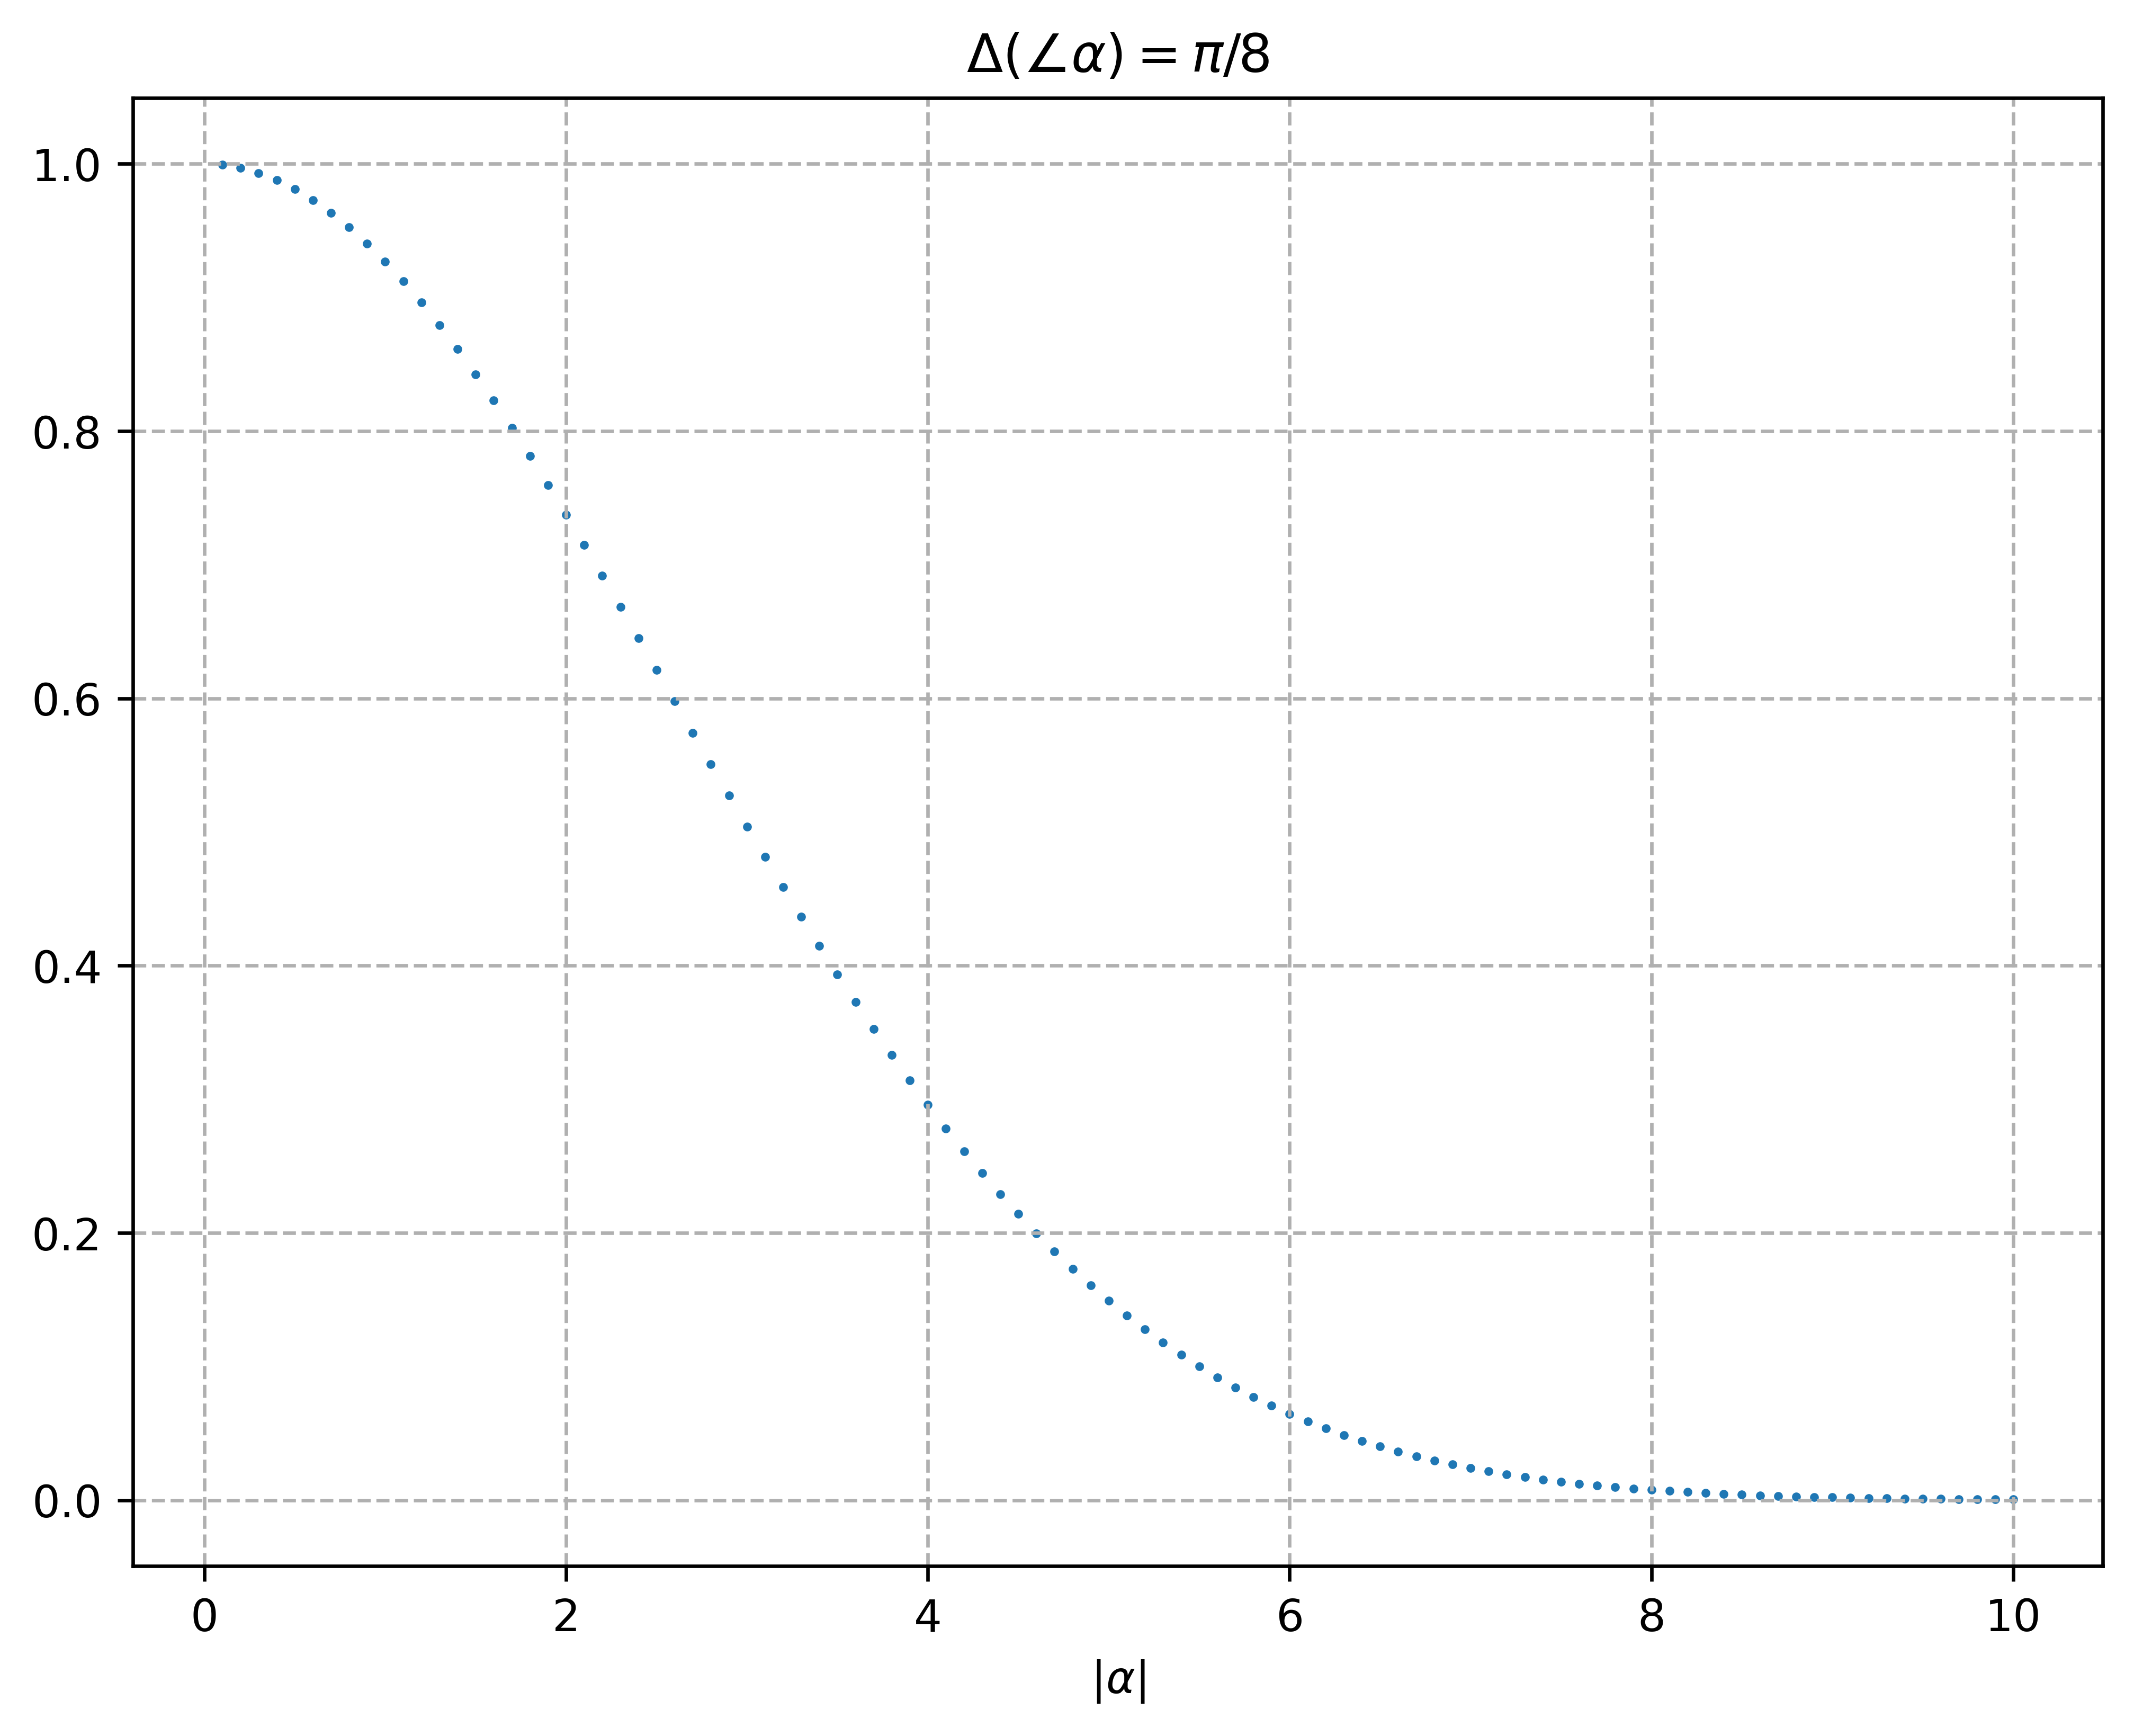

In [10]:
x_values = np.array(range(1, 101)) * 0.1
data = [
    #abs(np.exp(-0.5 * (2 - 2 * np.conj(beta) * alpha)) ** (x**2))
    np.abs(np.exp(-0.5 * (2 - 2 * np.exp(1j * -np.pi / 8))) ** (x**2))
    for x in x_values
]
plt.figure(figsize=(8, 6), dpi=600)
plt.scatter(x_values, data, s=1)
# plt.plot(x_values, data, linestyle='--', alpha=0.3)
plt.grid(True, which="both", ls="--")
plt.xlabel(r"$|\alpha|$")
plt.title(r"$\Delta{(\angle{\alpha})} = \pi/8$")
# plt.ylim(-0.01, 1.01)
plt.show()
# print(np.abs(overlap(alpha * 8, beta * 8)))

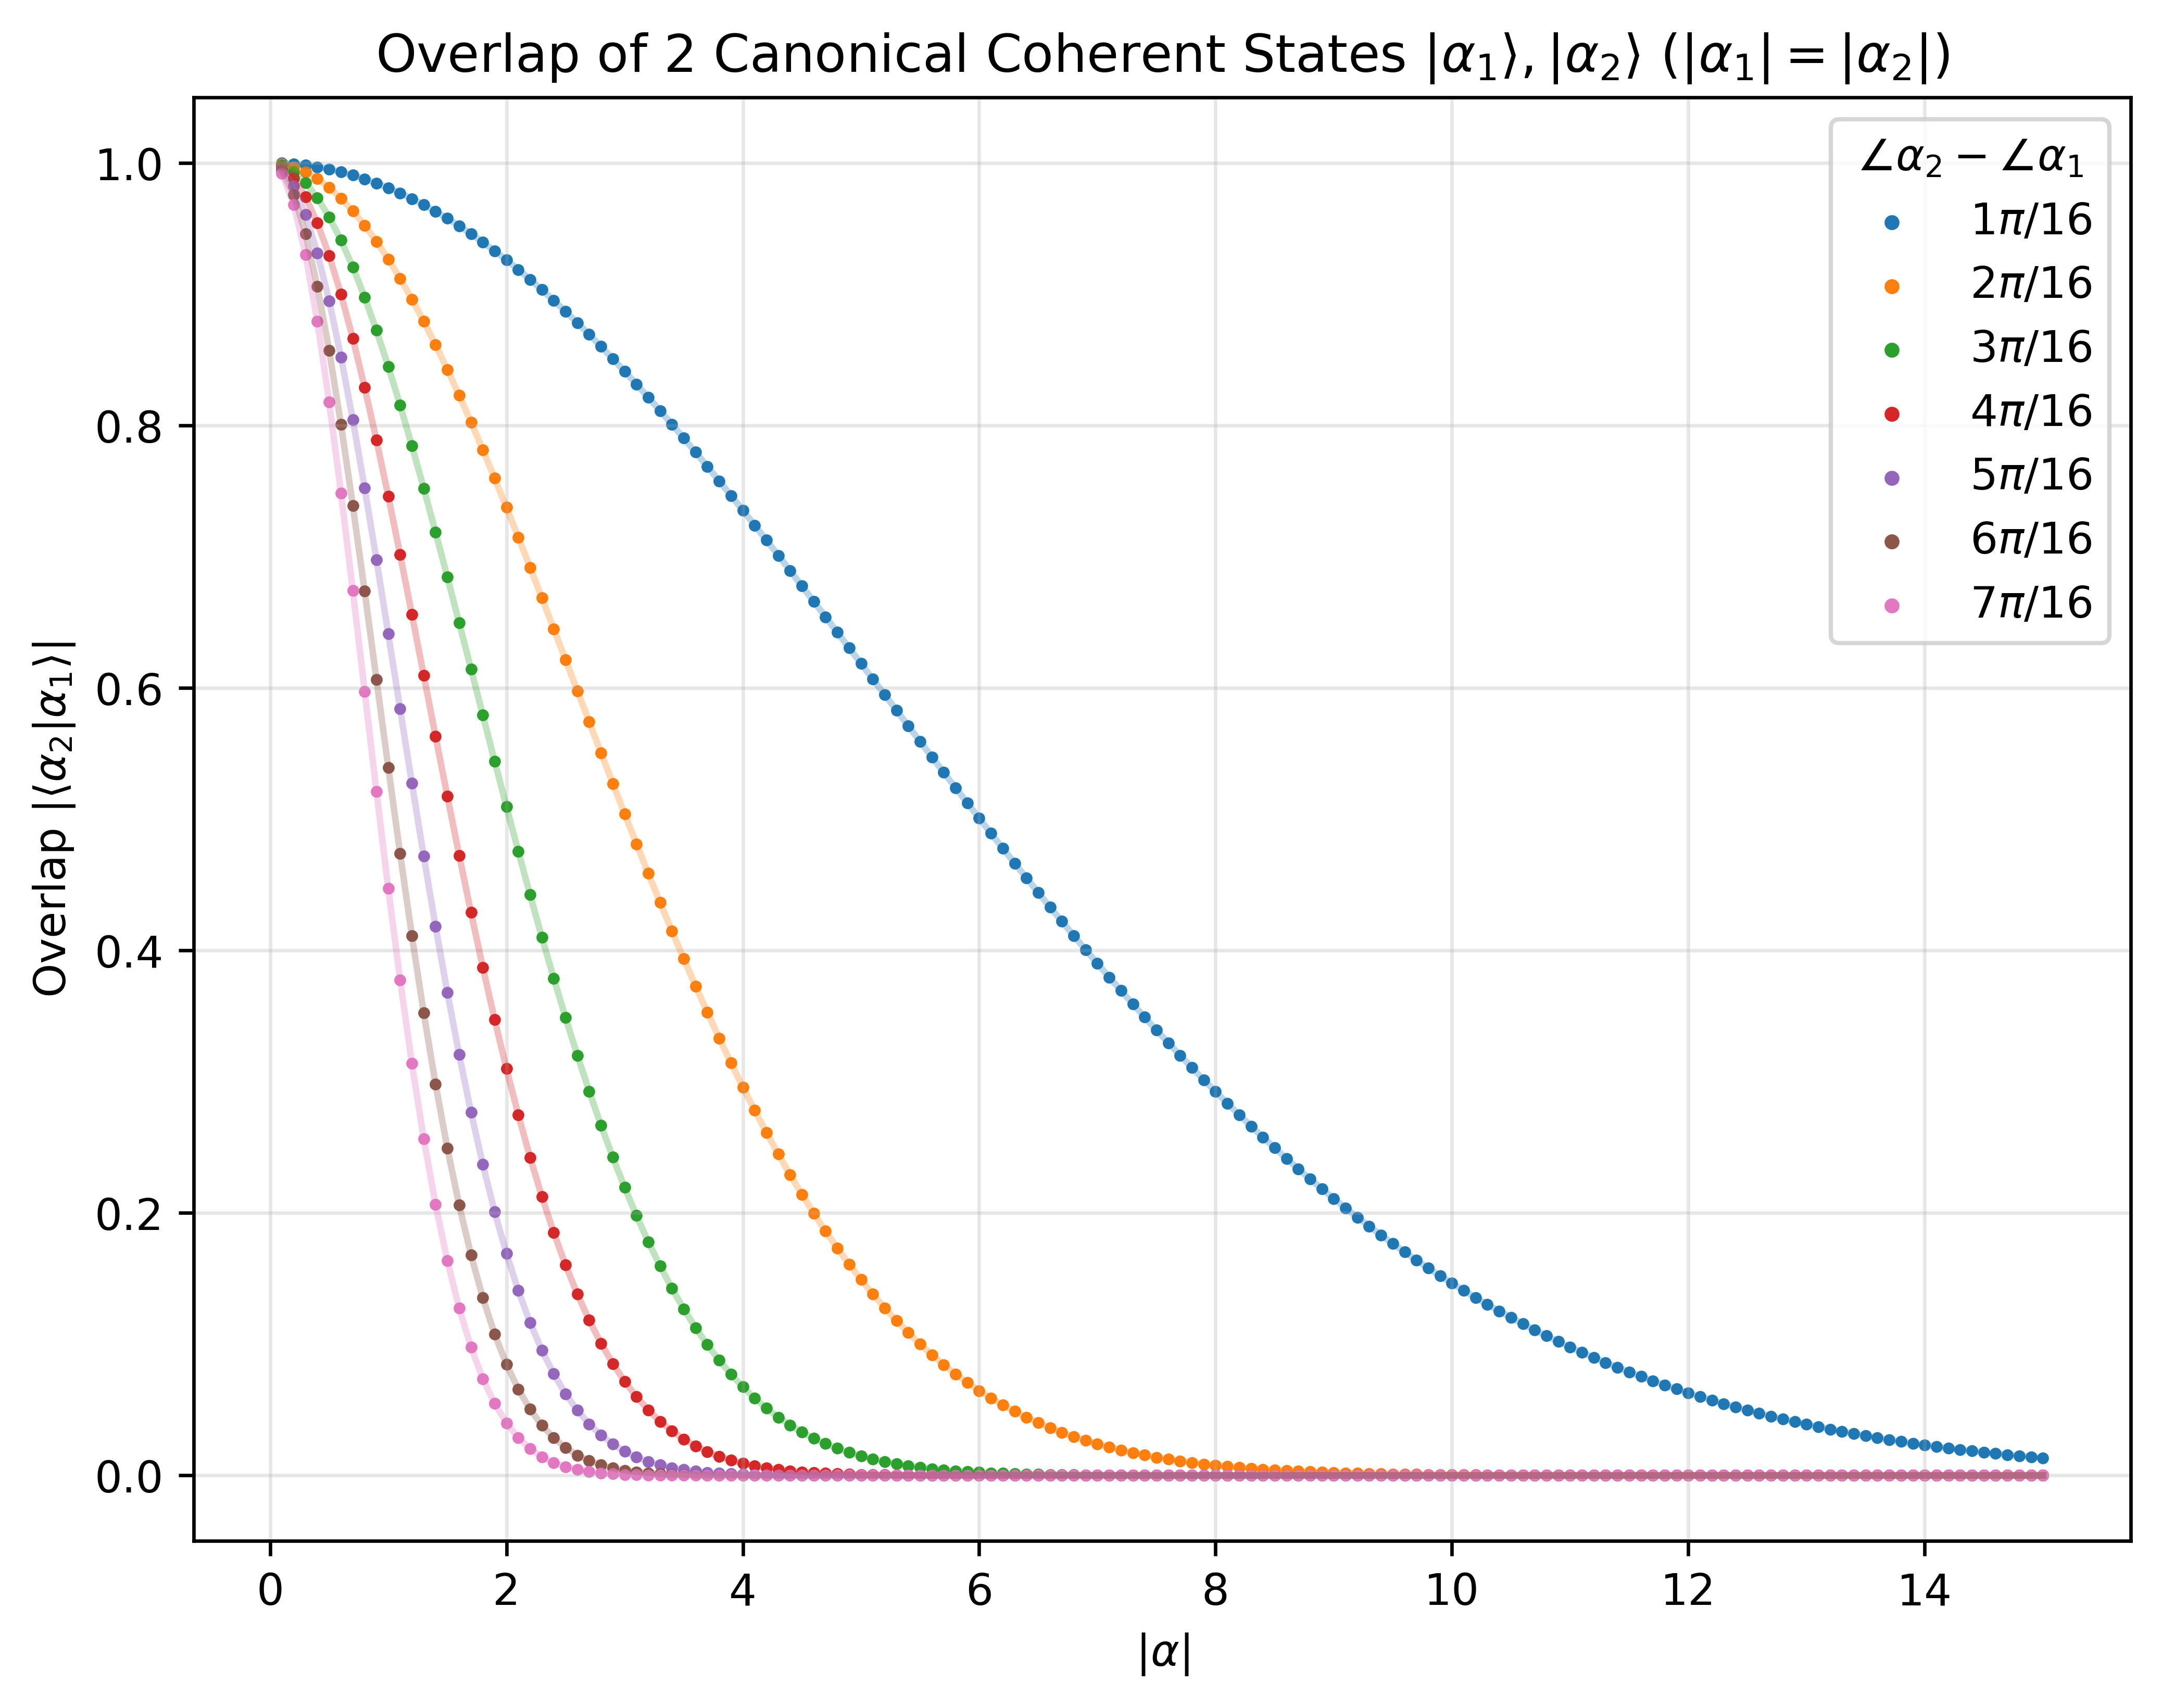

In [11]:
x_values = np.array(range(1, 151)) * 0.1
# angles = [i * np.pi / 32 for i in range(1, 16)]
angles = [i * np.pi / 16 for i in range(1, 8)]

plt.figure(figsize=(8, 6), dpi=600)
for i in range(len(angles)):
    data = [
        # abs(np.exp(-0.5 * (2 - 2 * np.conj(beta) * alpha)) ** (x**2))
        np.abs(np.exp(-0.5 * (2 - 2 * np.exp(1j * angles[i]))) ** (x**2))
        for x in x_values
    ]
    plt.scatter(x_values, data, s=3, label=rf"{i + 1}$\pi$/16")
    plt.plot(x_values, data, linestyle="-", alpha=0.3)
plt.grid(True, which="both", ls="-", alpha=0.3)

# Change the marker size manually for both lines
lgnd = plt.legend(title=r"$\angle{\alpha_{2}} - \angle{\alpha_{1}}$")
for handle in lgnd.legend_handles:
    handle.set_sizes([6.0])

plt.xlabel(r"$|\alpha|$")
plt.ylabel(r"Overlap $\left|\langle{\alpha_{2}}|{\alpha_{1}}\rangle\right|$")
plt.title(
    r"Overlap of 2 Canonical Coherent States $|\alpha_{1}\rangle, |\alpha_{2}\rangle$ ($|\alpha_{1}| = |\alpha_{2}|$)"
)
# plt.ylim(-0.01, 1.01)
plt.show()
# print(np.abs(overlap(alpha * 8, beta * 8)))

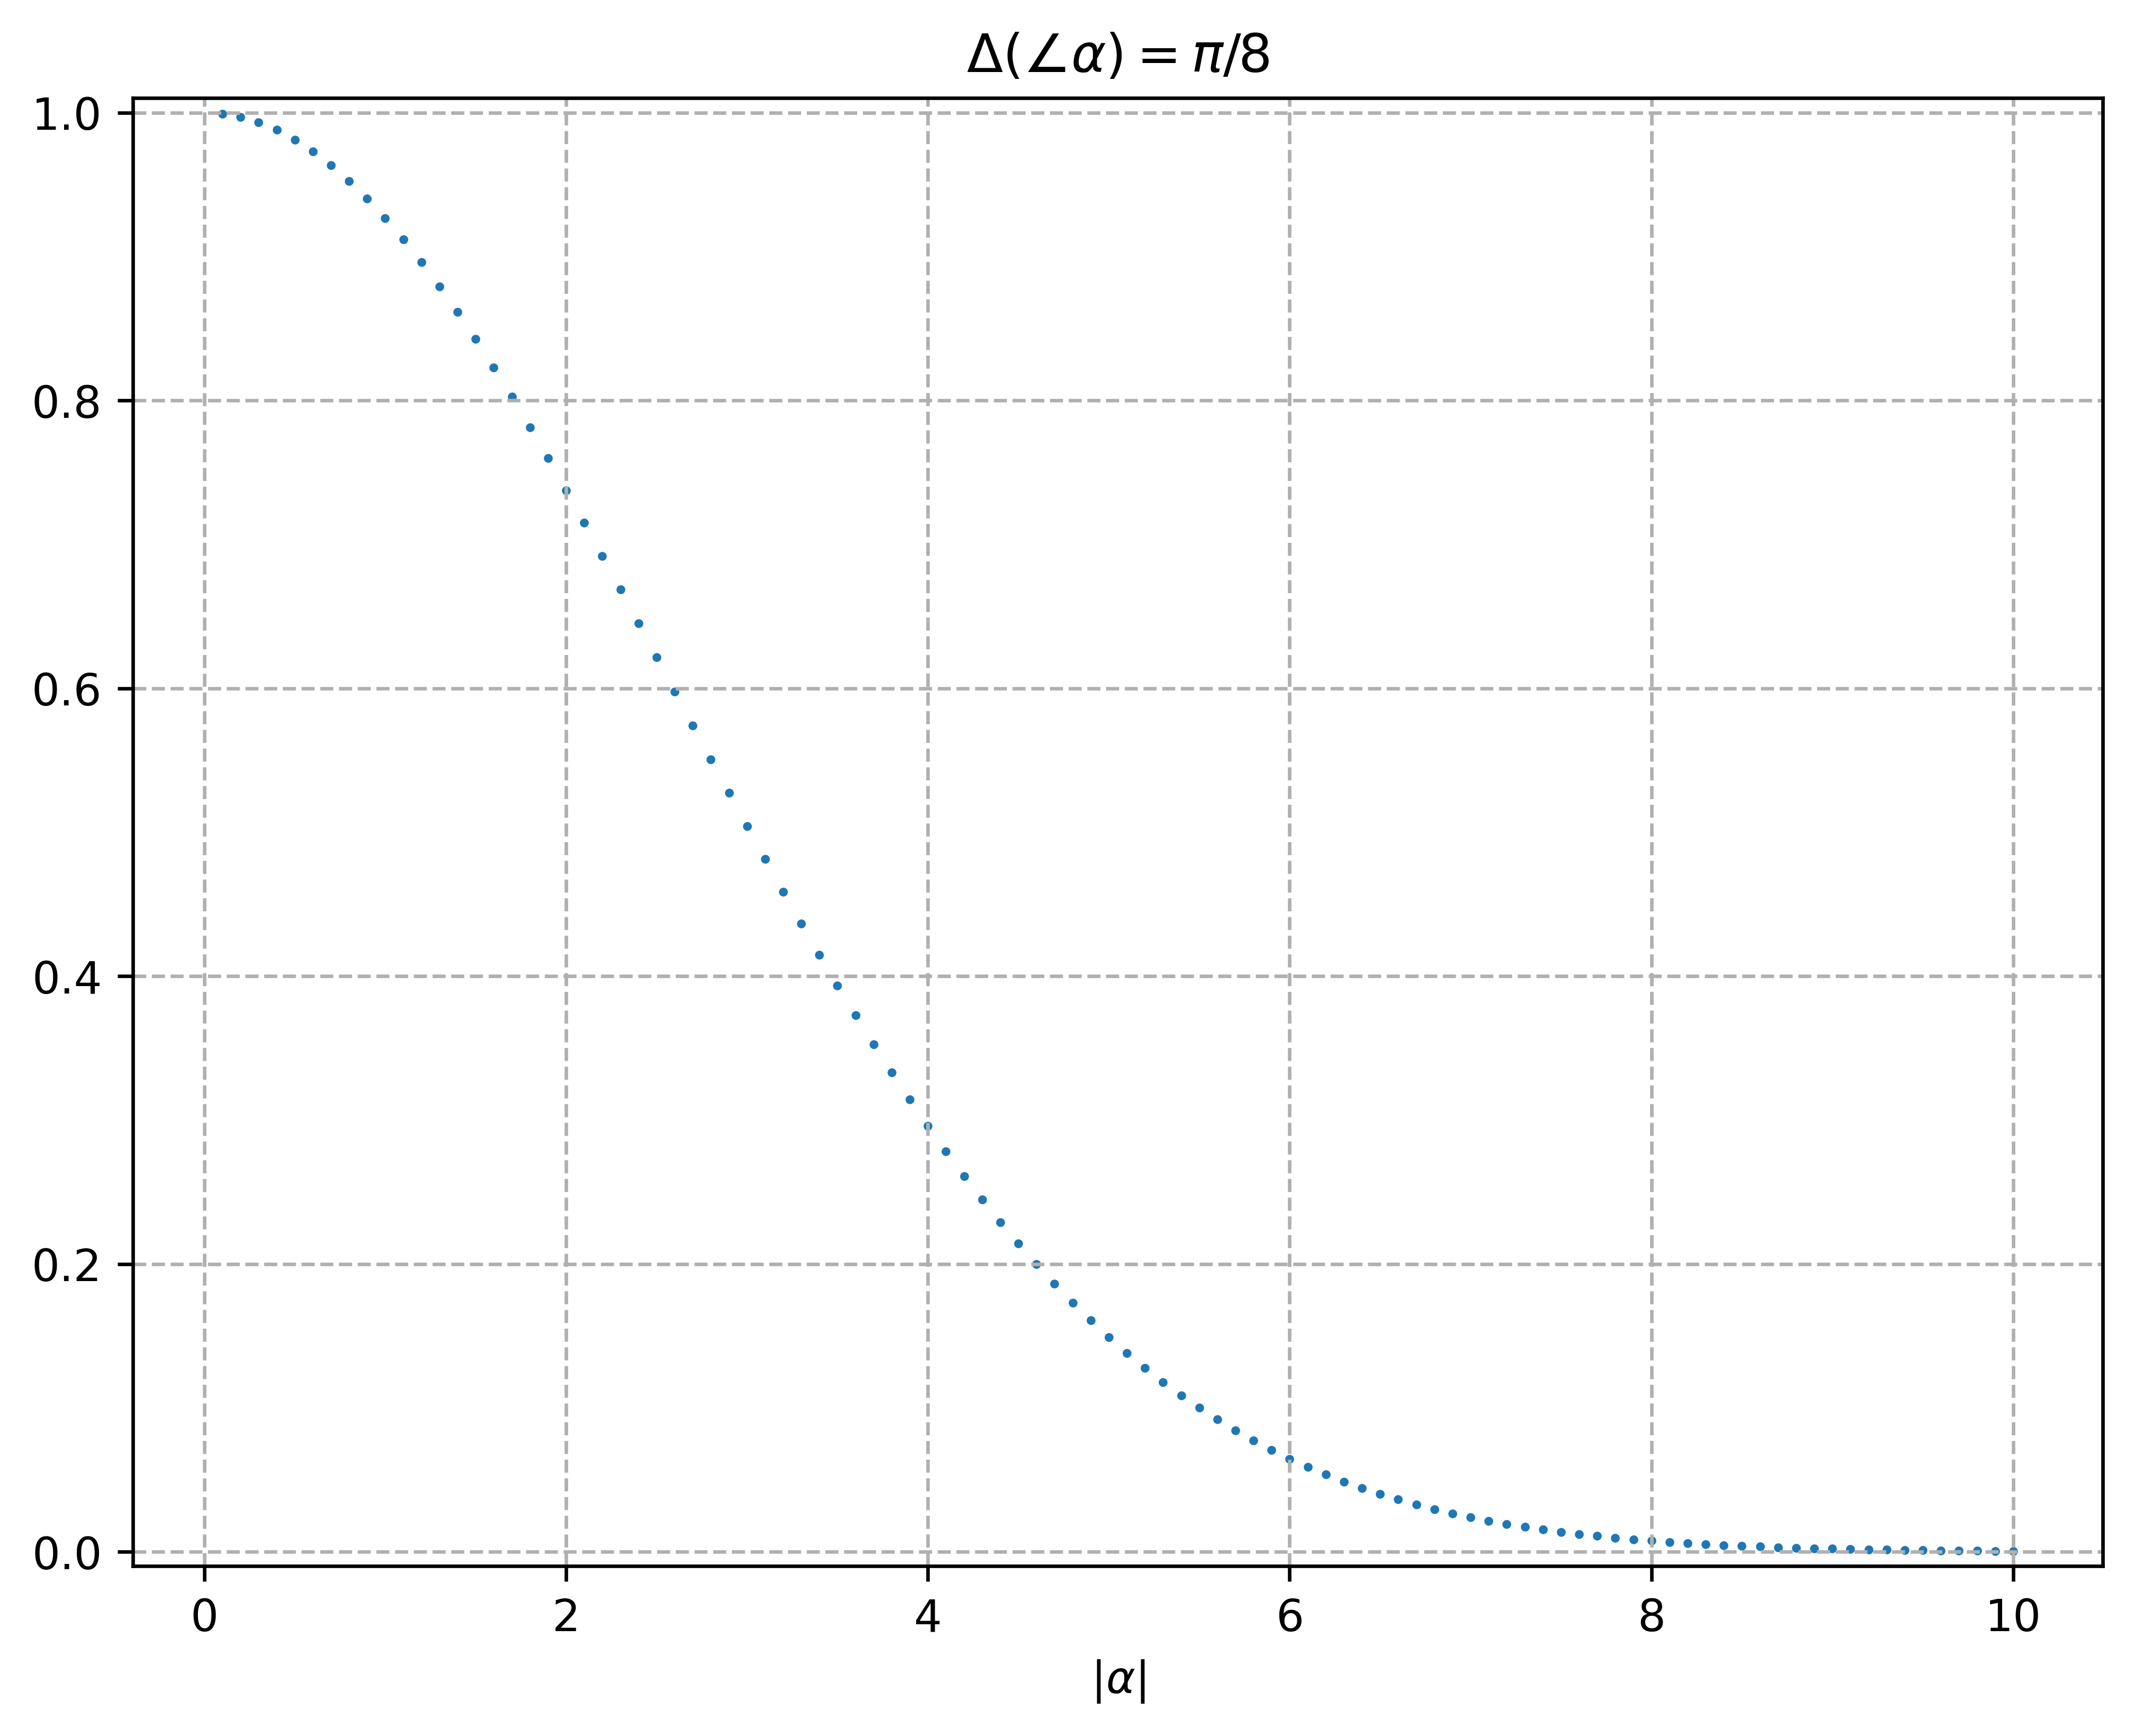

In [12]:
# 2pi/3
alpha = np.exp(1j * np.pi / 8)
beta = np.exp(1j * np.pi / 4)
data = []
data_2 = []
for i in range(1, 101):
    data.append(np.abs(overlap(alpha * 0.1 * i, beta * 0.1 * i)))
    data_2.append(f(alpha, beta))
# print(data)


x_values = np.array(range(1, 101)) * 0.1
plt.figure(figsize=(8, 6), dpi=600)
plt.scatter(x_values, data, s=1)
#plt.plot(x_values, data, linestyle='--', alpha=0.3)
plt.grid(True, which="both", ls="--")
plt.xlabel(r'$|\alpha|$')
plt.title(r'$\Delta{(\angle{\alpha})} = \pi/8$')
plt.ylim(-0.01, 1.01)
plt.show()
# print(np.abs(overlap(alpha * 8, beta * 8)))

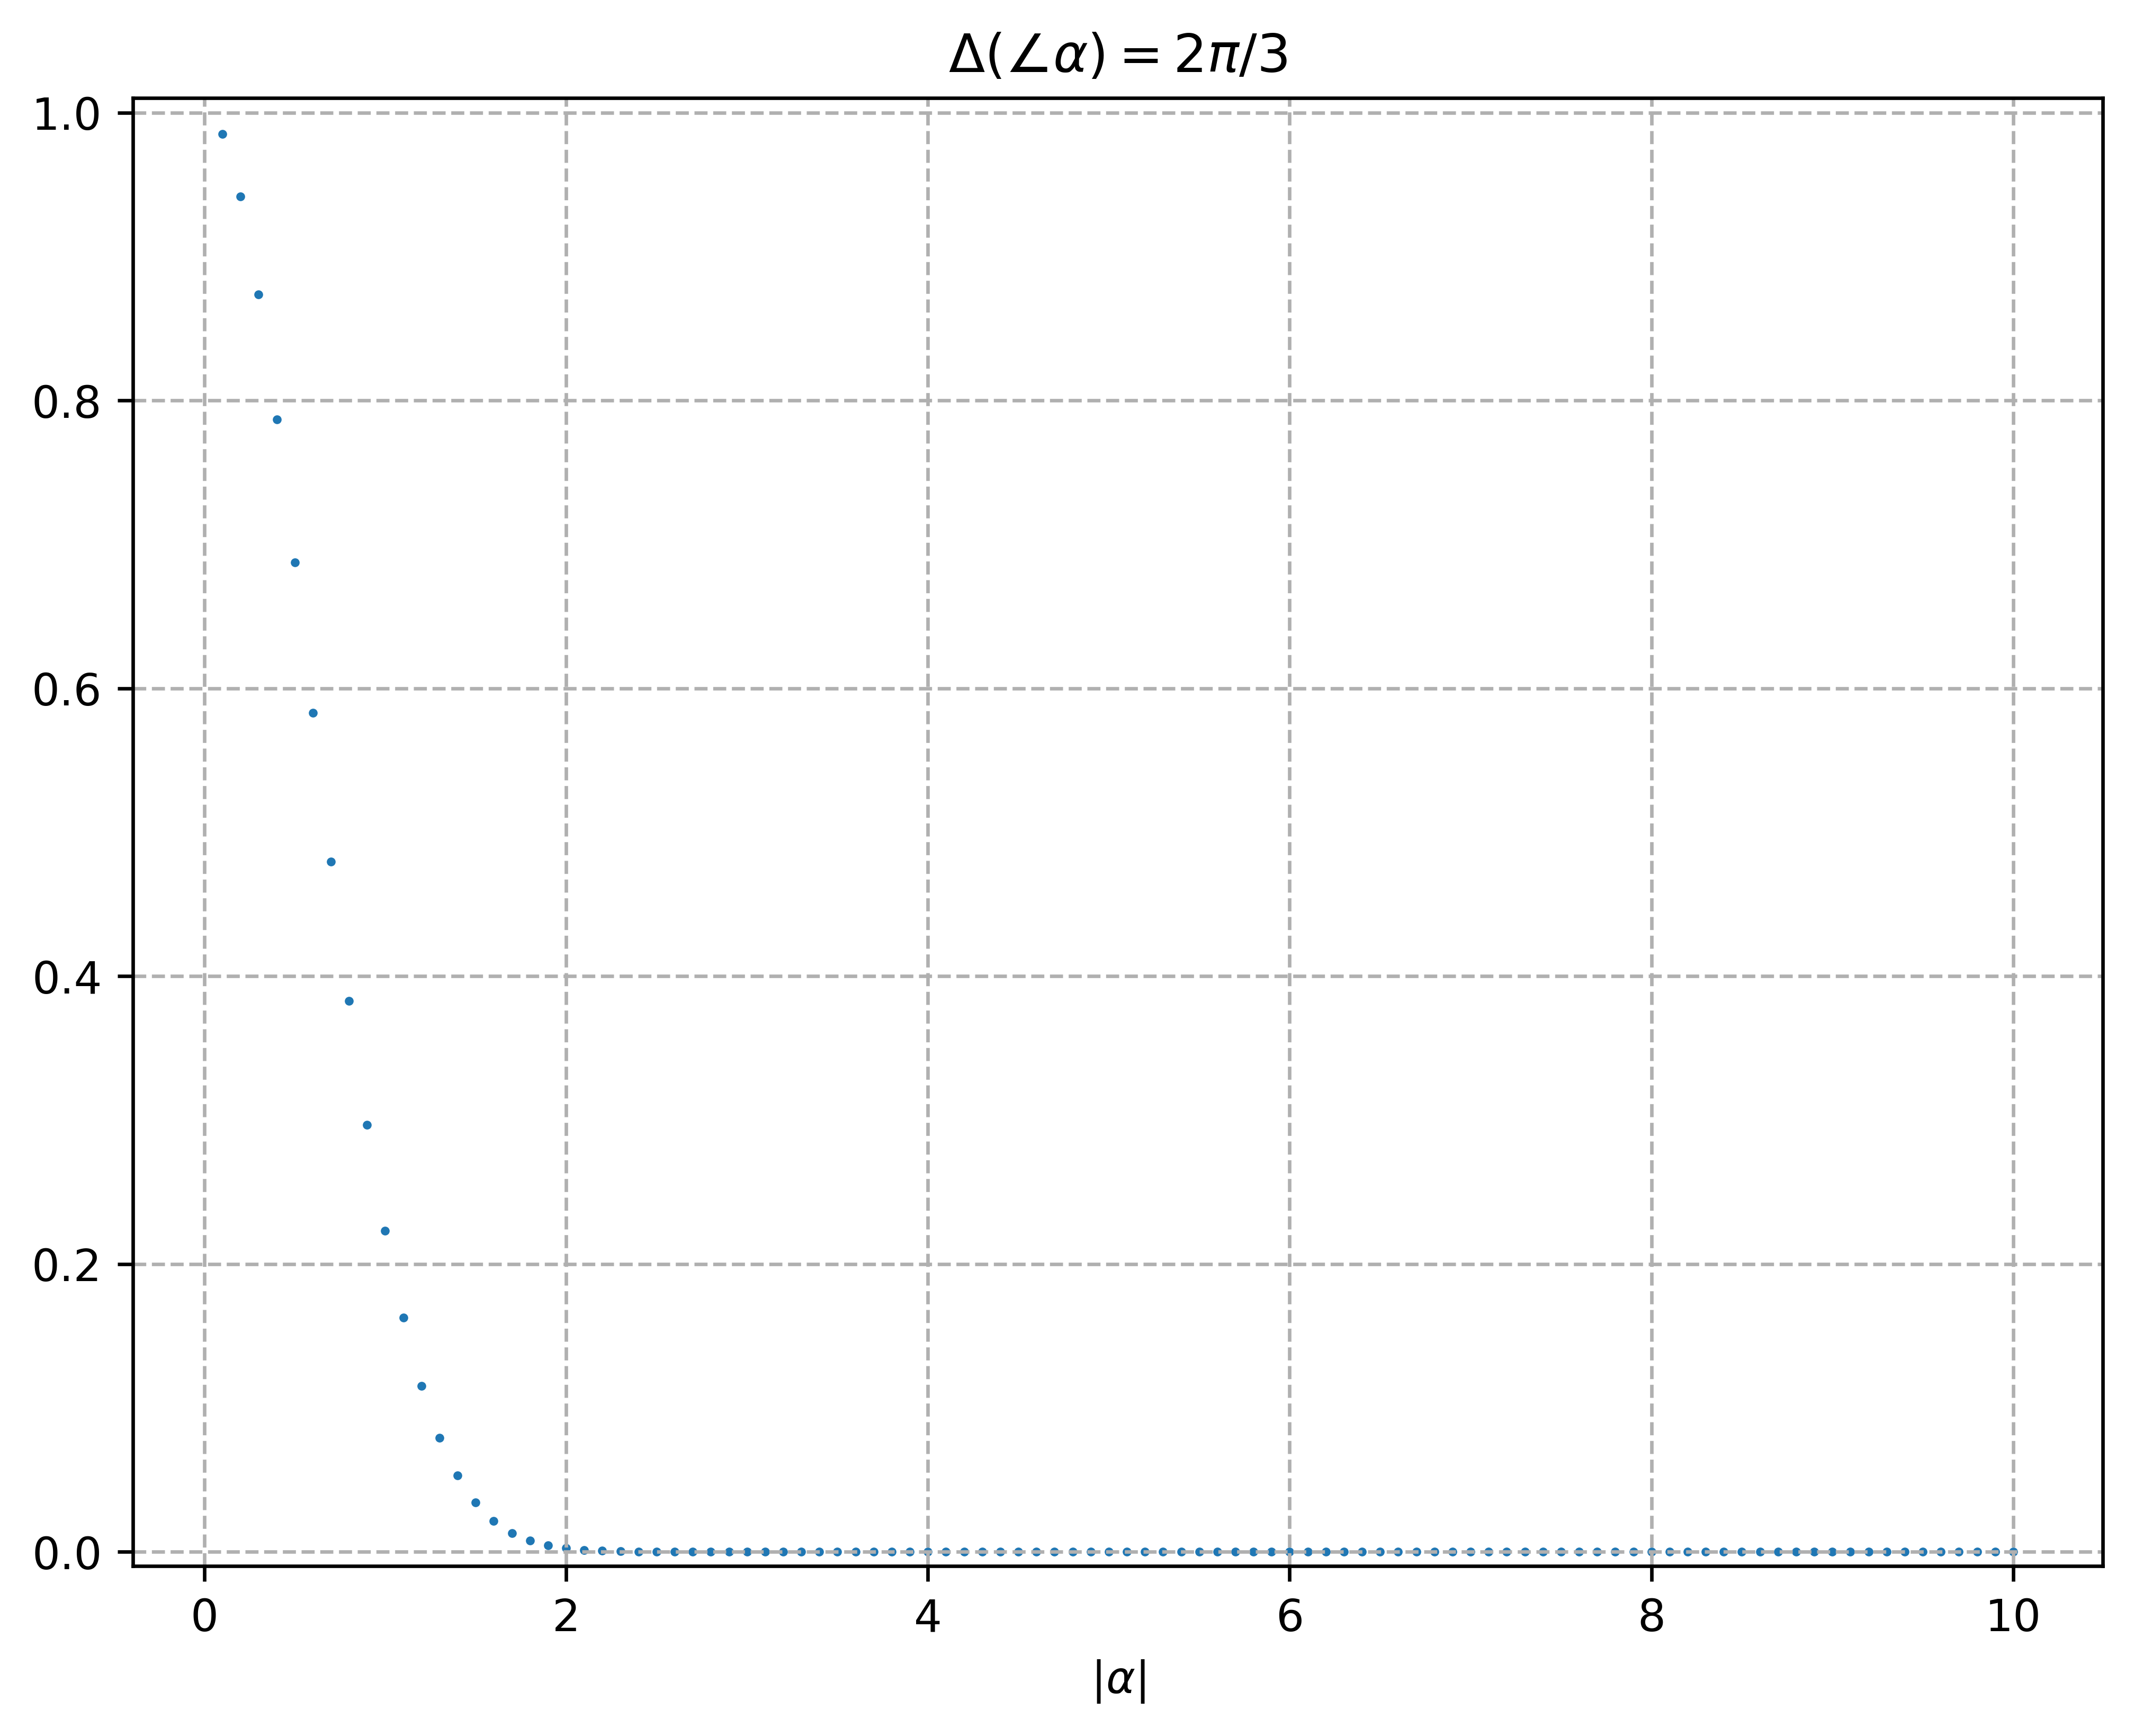

In [14]:
alpha = np.exp(0)
beta = np.exp(1j * 2 * np.pi / 3)
data = []
data_2 = []
for i in range(1, 101):
    data.append(np.abs(overlap(alpha * 0.1 * i, beta * 0.1 * i)))
    data_2.append(f(alpha, beta))
# print(data)


x_values = np.array(range(1, 101)) * 0.1
plt.figure(figsize=(8, 6), dpi=600)
plt.scatter(x_values, data, s=1)
#plt.plot(x_values, data, linestyle='--', alpha=0.3)
plt.grid(True, which="both", ls="--")
plt.xlabel(r'$|\alpha|$')
plt.title(r'$\Delta{(\angle{\alpha})} = 2\pi/3$')
plt.ylim(-0.01, 1.01)
plt.show()
# print(np.abs(overlap(alpha * 8, beta * 8)))